In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

from FEX.models import fex
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Using device: cuda


In [3]:
from data.generate_data import make_static_sf_adjacency
timesteps=5000
adj_matrix = make_static_sf_adjacency(100, 500, gamma_in=3.5, gamma_out=3.5)
print(torch.mean(adj_matrix.sum(dim=1))) # number of incoming edges (degree)


tensor(5.)


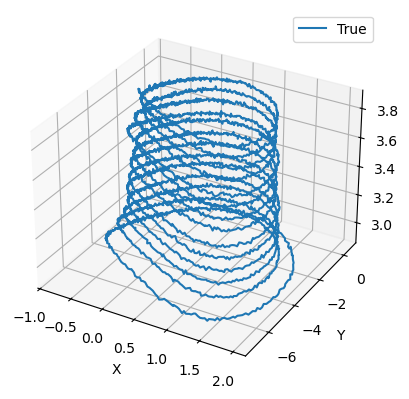

In [7]:
import matplotlib.pyplot as plt
from data.generate_data import make_timeseries
timeseries, t_derivs = make_timeseries(num_samples=5000, adjacency=adj_matrix, snr=45)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
node=10
ax.plot(timeseries[:, node, 0].cpu(), timeseries[:, node, 1].cpu(), timeseries[:, node, 2].cpu(), label='True')
ax.legend()
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

In [4]:
dimx_fex = fex.CoupledFEX('depth_3_leaves_4_config', 'depth_2_tree_config', 0, controller_epochs=300, controller_lr=0.005, finetune_epochs=5000, num_fex_epochs=100, self_lr=0.02, inter_lr=0.02, bfgs_epochs=30, bfgs_lr=0.6, poolsize=8, device=device, expression_threshold=0.1)
dimx_fex.fit(timeseries, t_derivs, adj_matrix, num_workers=5)

Using 5 parallel processes for candidate evaluation.
Using device: cuda
Evaluating candidate 0 on GPU 0
Using device: cuda
Using device: cuda
Using device: cuda
Evaluating candidate 1 on GPU 0
Evaluating candidate 2 on GPU 0
Evaluating candidate 3 on GPU 0
Using device: cuda
Evaluating candidate 4 on GPU 0
Evaluating candidate 5 on GPU 0
Evaluating candidate 6 on GPU 0
Evaluating candidate 7 on GPU 0
Evaluating candidate 8 on GPU 0
Evaluating candidate 9 on GPU 0
Evaluation time for fex epoch: 0.12 seconds
Epoch 0 pmfs: [array([[0.31967306, 0.34198213, 0.33834475]], dtype=float32), array([[0.35477182, 0.34709838, 0.2981298 ]], dtype=float32), array([[0.30162114, 0.37782326, 0.3205556 ]], dtype=float32), array([[0.14293106, 0.15857989, 0.12624577, 0.1397662 , 0.13345948,
        0.14691818, 0.15209942]], dtype=float32), array([[0.13245271, 0.164738  , 0.13683812, 0.15156461, 0.14004803,
        0.13553597, 0.13882257]], dtype=float32), array([[0.14587168, 0.13318262, 0.13057488, 0.15341

In [6]:
dimx_fex.finetune_lr = 0.002
dimx_fex.finetune(timeseries, t_derivs, adj_matrix)

Adam epoch   100/5000: pred_loss=1.84082539e-06, 
Adam epoch   200/5000: pred_loss=1.57524537e-05, 
Adam epoch   300/5000: pred_loss=4.41150464e-09, 
Adam epoch   400/5000: pred_loss=7.27085781e-04, 
Adam epoch   500/5000: pred_loss=1.40255964e-09, 
Adam epoch   600/5000: pred_loss=7.25366977e-05, 
Adam epoch   700/5000: pred_loss=1.07742560e-03, 
Adam epoch   800/5000: pred_loss=4.63968702e-09, 
Adam epoch   900/5000: pred_loss=9.45887554e-06, 
Adam epoch  1000/5000: pred_loss=5.90447263e-10, 
Adam epoch  1100/5000: pred_loss=3.50821909e-09, 
Adam epoch  1200/5000: pred_loss=9.95291083e-06, 
Adam epoch  1300/5000: pred_loss=9.87890156e-10, 
Adam epoch  1400/5000: pred_loss=1.92642814e-09, 
Adam epoch  1500/5000: pred_loss=5.20129804e-06, 
Adam epoch  1600/5000: pred_loss=9.18142862e-03, 
Adam epoch  1700/5000: pred_loss=3.18390820e-05, 
Adam epoch  1800/5000: pred_loss=6.88182899e-10, 
Adam epoch  1900/5000: pred_loss=1.31403008e-04, 
Adam epoch  2000/5000: pred_loss=3.75953807e-08, 


In [4]:
dimy_fex = fex.SingleFEX('depth_2_tree_config', 1, num_finetune_epochs=2000, controller_epochs=200, num_fex_epochs=60, device=device)
dimy_fex.fit(data, derivatives, num_workers=5)

Using 5 parallel processes for candidate evaluation.
Using device: cuda
Evaluating candidate 0 on GPU 0
Using device: cuda
Evaluating candidate 1 on GPU 0
Using device: cuda
Evaluating candidate 2 on GPU 0
Using device: cuda
Evaluating candidate 3 on GPU 0
Using device: cuda
Evaluating candidate 4 on GPU 0
Evaluating candidate 5 on GPU 0
Evaluating candidate 6 on GPU 0
Evaluating candidate 7 on GPU 0
Evaluating candidate 8 on GPU 0
Evaluating candidate 9 on GPU 0
Evaluation time for fex epoch: 0.06 seconds
Epoch 0, pmfs: [array([[0.2751417 , 0.34819484, 0.3766635 ]], dtype=float32), array([[0.13144317, 0.1577706 , 0.14929031, 0.14572486, 0.12679051,
        0.14353877, 0.14544179]], dtype=float32), array([[0.15806364, 0.14400022, 0.15673748, 0.12700418, 0.14308317,
        0.1504249 , 0.12068645]], dtype=float32)]
Evaluating candidate 0 on GPU 0
Evaluating candidate 1 on GPU 0
Evaluating candidate 2 on GPU 0
Evaluating candidate 3 on GPU 0
Evaluating candidate 4 on GPU 0
Evaluating can

In [5]:
dimz_fex = fex.SingleFEX('depth_3_leaves_4_config', 2, controller_epochs=250, num_finetune_epochs=5000, num_fex_epochs=80, device=device)
dimz_fex.fit(data, derivatives, num_workers=5)

Using 5 parallel processes for candidate evaluation.
Using device: cudaUsing device: cuda
Using device: cudaUsing device: cuda


Using device: cuda
Evaluating candidate 0 on GPU 0
Evaluating candidate 1 on GPU 0
Evaluating candidate 2 on GPU 0
Evaluating candidate 3 on GPU 0
Evaluating candidate 4 on GPU 0
Evaluating candidate 5 on GPU 0
Evaluating candidate 6 on GPU 0
Evaluating candidate 7 on GPU 0
Evaluating candidate 8 on GPU 0
Evaluating candidate 9 on GPU 0
Evaluation time for fex epoch: 0.09 seconds
Epoch 0, pmfs: [array([[0.31875235, 0.3063185 , 0.37492916]], dtype=float32), array([[0.34230277, 0.31492686, 0.34277043]], dtype=float32), array([[0.3362107 , 0.3054065 , 0.35838282]], dtype=float32), array([[0.13282171, 0.1552179 , 0.13594335, 0.16381374, 0.16107325,
        0.12308452, 0.12804551]], dtype=float32), array([[0.15170082, 0.14509612, 0.15893684, 0.11742   , 0.15621233,
        0.13462783, 0.136006  ]], dtype=float32), array([[0.14250314, 0.13203818, 0.12727381, 0.1651

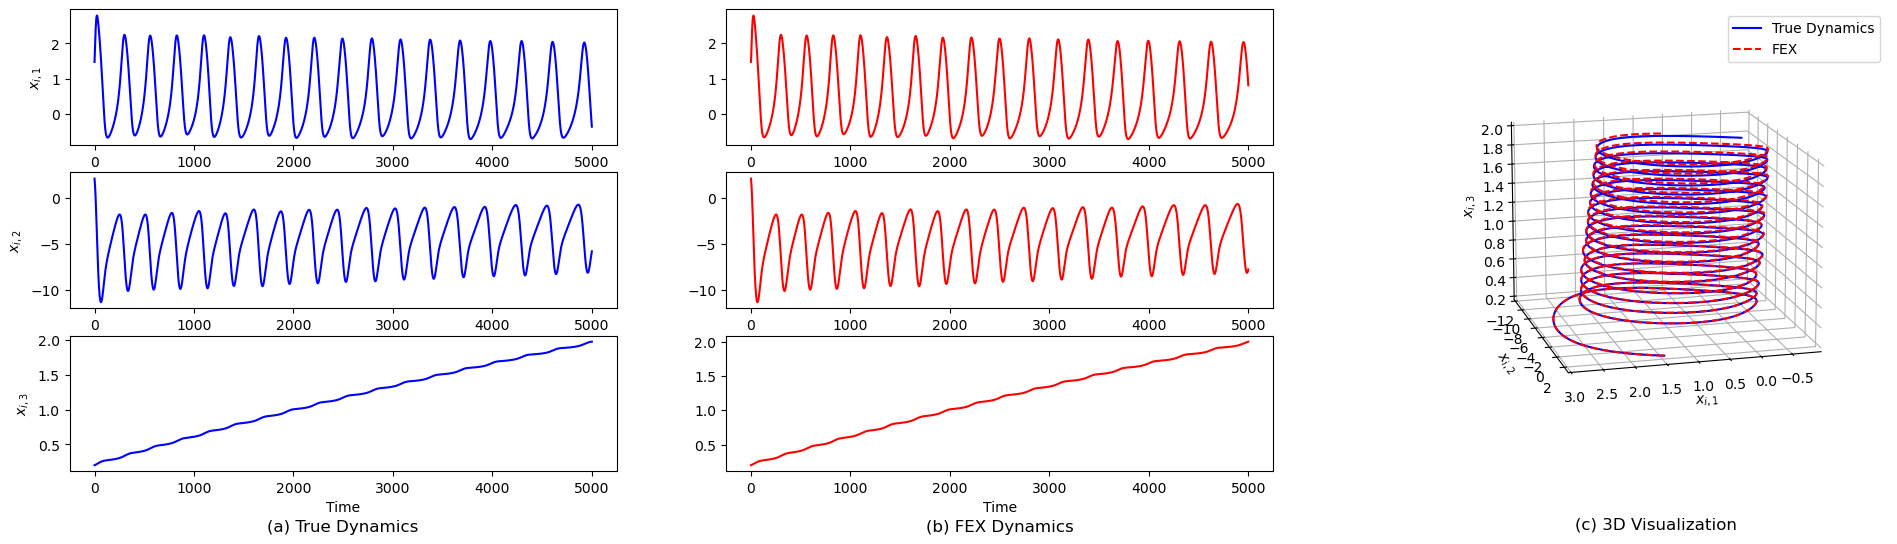

In [ ]:
# recovered self = -1.0*x1**3 + 3.0*x1**2 + 1.0*x2 - 0.9999*x3 + 3.24
# recovered inter = (0.3000816 - 0.14999958*x1)*exp(x4)/(exp(x4) + 1)
def temp_dimx_fex_predict(state, adj_matrix):
    state = state.to(device)
    adj_matrix = adj_matrix.to(device)
    x1 = state[:, 0:1]
    x2 = state[:, 1:2]
    x3 = state[:, 2:3]
    self_out = -1.0*x1**3 + 3.0*x1**2 + 1.0*x2 - 0.9999*x3 + 3.24
    coupling = adj_matrix @ torch.sigmoid(x1)
    inter_out = (0.3000816 - 0.14999958*x1) * coupling
    return self_out + inter_out

predicted_states = torch.zeros(timesteps + 1, timeseries.size(1), timeseries.size(2), device='cpu')
predicted_states[0] = timeseries[0]
dt = 0.01
with torch.no_grad():
    for t in range(timesteps):
        state = predicted_states[t]
        dx_dt = temp_dimx_fex_predict(state, adj_matrix)
        dy_dt = dimy_fex.predict(state)
        dz_dt = dimz_fex.predict(state)
        deriv = torch.cat([
            dx_dt.cpu(),
            dy_dt.cpu(),
            dz_dt.cpu()
        ], dim=-1)

        predicted_states[t+1] = state + dt * deriv

        if not torch.isfinite(predicted_states[t+1]).all():
            print(f"Non-finite state at timestep {t + 1}")
            break
        
from FEX.utils.plots import plot_dynamics

node = 10
fig = plot_dynamics(timeseries[:, node, 0].cpu(), timeseries[:, node, 1].cpu(), timeseries[:, node, 2].cpu(), predicted_states[:, node, :].cpu(), elev=15, azim=75)
plt.show()

In [1]:
from FEX.utils.metrics import sMAPE

ground_truth_self_str = "-1.0*x1**3 + 3.0*x1**2 + 1.0*x2 - 1.0*x3 + 3.24"
ground_truth_inter_str = "(0.3 - 0.15*x1)*exp(x4)/(exp(x4) + 1)"

pred_self_str = '-1.0*x1**3 + 3.0*x1**2 + 1.0*x2 - 0.9999*x3 + 3.24'
pred_inter_str = '(0.3000816 - 0.14999958*x1)*exp(x4)/(exp(x4) + 1)'
smape_self = sMAPE(ground_truth_self_str, pred_self_str)
smape_inter = sMAPE(ground_truth_inter_str, pred_inter_str)
print("sMAPE for self dynamics:", smape_self)
print("sMAPE for inter dynamics:", smape_inter)
print("total sMAPE:", smape_self + smape_inter)

Using device: cuda
All terms: {1, x1**2, x2, x3, x1**3}
All terms: {exp(x4)/(exp(x4) + 1), x1*exp(x4)/(exp(x4) + 1)}
sMAPE for self dynamics: 0.001000050002500015
sMAPE for inter dynamics: 0.006869075423757247
total sMAPE: 0.007869125426257262
